In [1]:
import os
import glob
import numpy as np
import rasterio
import pandas as pd
from tqdm.auto import tqdm


DATA_DIR = "../data"

crops = [
    "corn",
    "barley",
    "wheat",
    "rice",
    "kolza"
]


T = 12

BANDS_PER_DATE = 10

# Sentinel-2 band indexes inside each timestep
B4_INDEX = 2   # Red
B8_INDEX = 6   # NIR


RESULTS = []

In [2]:
import numpy as np
import rasterio


def extract_ndvi_timeseries(tif_path):
    """
    Read only the red and NIR bands from a Sentinel-2 temporal stack
    and return a T-step mean NDVI phenology curve.

    Assumptions
    -----------
    - Bands are ordered by date.
    - Each date contains BANDS_PER_DATE bands.
    - B4_INDEX and B8_INDEX are zero-based indices within each date.
    """

    # Rasterio band numbers are 1-based
    red_band_ids = [
        (t * BANDS_PER_DATE) + B4_INDEX + 1
        for t in range(T)
    ]

    nir_band_ids = [
        (t * BANDS_PER_DATE) + B8_INDEX + 1
        for t in range(T)
    ]

    band_ids = red_band_ids + nir_band_ids

    with rasterio.open(tif_path) as src:
        data = src.read(
            band_ids,
            out_dtype="float32",
            masked=True,
        )

    red = data[:T]
    nir = data[T:]

    denominator = nir + red

    ndvi = np.ma.divide(
        nir - red,
        denominator,
    )

    # Mean over all valid parcel pixels
    ndvi_curve = np.ma.mean(
        ndvi.reshape(T, -1),
        axis=1,
    )

    return ndvi_curve.filled(np.nan).astype(np.float32)

In [3]:
def phenology_score(ndvi):
    """
    Returns activity score 0-100
    """

    score = 0


    ndvi_min = np.min(ndvi)
    ndvi_max = np.max(ndvi)


    amplitude = ndvi_max - ndvi_min


    # 1. NDVI amplitude
    if amplitude > 0.15:
        score += 30

    elif amplitude > 0.08:
        score += 15



    # 2. Temporal variation

    std = np.std(ndvi)

    if std > 0.08:
        score += 20

    elif std > 0.04:
        score += 10



    # 3. Growth phase

    diff = np.diff(ndvi)


    max_growth = np.max(diff)


    if max_growth > 0.08:
        score += 20

    elif max_growth > 0.04:
        score += 10



    # 4. Senescence / harvest decline

    min_decline = np.min(diff)


    if min_decline < -0.08:
        score += 20

    elif min_decline < -0.04:
        score += 10



    # 5. Peak existence

    peak_ratio = ndvi_max * 0.8

    peak_length = np.sum(
        ndvi > peak_ratio
    )


    if peak_length >= 2:
        score += 10



    return min(score,100)

In [4]:
for crop in crops:

    files = glob.glob(
        os.path.join(
            DATA_DIR,
            crop,
            "s2",
            "*.tif"
        )
    )


    print(
        f"{crop}: {len(files)} files"
    )


    for tif in tqdm(files):

        try:

            ndvi = extract_ndvi_timeseries(
                tif
            )


            score = phenology_score(
                ndvi
            )


            RESULTS.append(
                {
                    "crop": crop,
                    "file": os.path.basename(tif),

                    "ndvi_min": float(ndvi.min()),
                    "ndvi_max": float(ndvi.max()),
                    "ndvi_amp": float(
                        ndvi.max()-ndvi.min()
                    ),

                    "activity_score": score,

                    "active":
                        score >= 60,

                    "ndvi_curve":
                        ndvi.tolist()
                }
            )


        except Exception as e:

            print(
                "FAILED:",
                tif,
                e
            )

corn: 1581 files


  0%|          | 0/1581 [00:00<?, ?it/s]

barley: 1638 files


  0%|          | 0/1638 [00:00<?, ?it/s]

FAILED: ../data/barley/s2/s2_y2018_p7598_full.tif '../data/barley/s2/s2_y2018_p7598_full.tif' not recognized as being in a supported file format.
wheat: 1513 files


...

rice: 1644 files


  0%|          | 0/1644 [00:00<?, ?it/s]

FAILED: ../data/rice/s2/s2_y2019_p0200_full.tif '../data/rice/s2/s2_y2019_p0200_full.tif' not recognized as being in a supported file format.
kolza: 1461 files


  0%|          | 0/1461 [00:00<?, ?it/s]

FAILED: ../data/kolza/s2/s2_y2018_p5336_full.tif '../data/kolza/s2/s2_y2018_p5336_full.tif' not recognized as being in a supported file format.


In [5]:
df = pd.DataFrame(
    RESULTS
)


df.head()

,crop,file,ndvi_min,ndvi_max,ndvi_amp,activity_score,active,ndvi_curve
0,corn,s2_y2018_p2881_full.tif,NaN,NaN,NaN,0,False,"[0.6938684582710266, 0.5567774176597595, 0.391..."
1,corn,s2_y2018_p2823_full.tif,NaN,NaN,NaN,0,False,"[0.8524033427238464, 0.762188732624054, 0.6629..."
2,corn,s2_y2018_p5594_full.tif,NaN,NaN,NaN,0,False,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ..."
3,corn,s2_y2018_p5483_full.tif,NaN,NaN,NaN,0,False,"[nan, 0.6836100220680237, 0.6836100220680237, ..."
4,corn,s2_y2018_p1112_full.tif,NaN,NaN,NaN,0,False,"[0.8084254264831543, 0.8084254264831543, nan, ..."


In [8]:
df[df['active'] == True]

,crop,file,ndvi_min,ndvi_max,ndvi_amp,activity_score,active,ndvi_curve
389,corn,s2_y2018_p4612_full.tif,0.233266,0.815552,0.582286,100,True,"[0.3822953701019287, 0.5572586059570312, 0.557..."
396,corn,s2_y2018_p4646_full.tif,0.178650,0.413661,0.235011,80,True,"[0.20478035509586334, 0.32731735706329346, 0.3..."
431,corn,s2_y2018_p5526_full.tif,0.366671,0.811076,0.444405,100,True,"[0.3666706681251526, 0.5433077216148376, 0.543..."
492,corn,s2_y2018_p4750_full.tif,0.421123,0.762353,0.341230,100,True,"[0.4211231470108032, 0.5588431358337402, 0.558..."
587,corn,s2_y2018_p6570_full.tif,0.167939,0.721219,0.553280,100,True,"[0.16793929040431976, 0.25290560722351074, 0.2..."
...,...,...,...,...,...,...,...,...
7824,kolza,s2_y2018_p1370_full.tif,0.099773,0.790715,0.690942,90,True,"[0.09977293759584427, 0.5049188137054443, 0.34..."
7825,kolza,s2_y2018_p9014_full.tif,0.223811,0.827193,0.603382,100,True,"[0.22381116449832916, 0.6649662852287292, 0.75..."
7826,kolza,s2_y2018_p3908_full.tif,0.100726,0.862043,0.761317,80,True,"[0.106165811419487, 0.106165811419487, 0.10072..."
7828,kolza,s2_y2018_p7892_full.tif,-0.035361,0.577344,0.612705,90,True,"[0.12394922971725464, 0.1302153319120407, 0.16..."


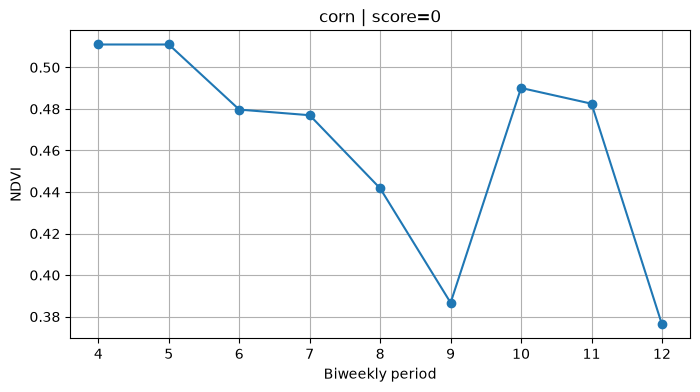

In [15]:
import matplotlib.pyplot as plt


def plot_sample(row):

    plt.figure(figsize=(8,4))

    plt.plot(
        range(1,13),
        row["ndvi_curve"],
        marker="o"
    )

    plt.title(
        f"{row.crop} | score={row.activity_score}"
    )

    plt.xlabel(
        "Biweekly period"
    )

    plt.ylabel(
        "NDVI"
    )

    plt.grid()

    plt.show()



plot_sample(
    df.iloc[5]
)